In [1]:
import pandas as pd
import numpy as np

optimized_plan = pd.read_csv(
    "../data/processed/optimized_plan.csv",
    parse_dates=["date"]
)

optimized_plan.head()

,date,item,forecast_demand,production,inventory,backlog
0,2017-07-09,1,2277.337242,2277.337242,0.0,0.000000
1,2017-07-09,2,5908.763850,5908.763850,0.0,0.000000
2,2017-07-09,3,3664.159003,0.000000,0.0,3664.159003
3,2017-07-09,4,2222.600935,2222.600935,0.0,0.000000
4,2017-07-09,5,1895.791759,1895.791759,0.0,0.000000


In [2]:
print("Rows:", len(optimized_plan))
print("Items:", optimized_plan["item"].nunique())
print("Weeks:", optimized_plan["date"].nunique())

Rows: 520
Items: 20
Weeks: 26


In [3]:
np.random.seed(42)

optimized_plan["actual_demand"] = (
    optimized_plan["forecast_demand"]
    * np.random.normal(
        loc=1.0,
        scale=0.10,
        size=len(optimized_plan)
    )
)

optimized_plan["actual_demand"] = (
    optimized_plan["actual_demand"]
    .clip(lower=0)
)

optimized_plan.head()

,date,item,forecast_demand,production,inventory,backlog,actual_demand
0,2017-07-09,1,2277.337242,2277.337242,0.0,0.000000,2390.455805
1,2017-07-09,2,5908.763850,5908.763850,0.0,0.000000,5827.066740
2,2017-07-09,3,3664.159003,0.000000,0.0,3664.159003,3901.482381
3,2017-07-09,4,2222.600935,2222.600935,0.0,0.000000,2561.109694
4,2017-07-09,5,1895.791759,1895.791759,0.0,0.000000,1851.401156


In [6]:
simulation = []

for item in sorted(optimized_plan["item"].unique()):

    item_data = (
        optimized_plan[
            optimized_plan["item"] == item
        ]
        .sort_values("date")
    )

    inventory = 0

    for _, row in item_data.iterrows():

        available = inventory + row["production"]

        actual_demand = row["actual_demand"]

        sales = min(
            available,
            actual_demand
        )

        ending_inventory = available - sales

        stockout = actual_demand - sales

        simulation.append({
            "date": row["date"],
            "item": item,
            "forecast_demand": row["forecast_demand"],
            "actual_demand": actual_demand,
            "production": row["production"],
            "sales": sales,
            "ending_inventory": ending_inventory,
            "stockout": stockout
        })

        inventory = ending_inventory

simulation = pd.DataFrame(simulation)

In [7]:
print("Total actual demand:",
      simulation["actual_demand"].sum())

print("Total sales:",
      simulation["sales"].sum())

print("Total stockout:",
      simulation["stockout"].sum())

print("Final inventory:",
      simulation.groupby("item")["ending_inventory"].last().sum())

Total actual demand: 2318595.8256152887
Total sales: 1978177.1700779255
Total stockout: 340418.65553736326
Final inventory: 337087.47434621205


In [8]:
service_level = (
    simulation["sales"].sum()
    / simulation["actual_demand"].sum()
)

stockout_rate = (
    simulation["stockout"].sum()
    / simulation["actual_demand"].sum()
)

print(f"Service Level: {service_level:.2%}")
print(f"Stockout Rate: {stockout_rate:.2%}")

Service Level: 85.32%
Stockout Rate: 14.68%


In [10]:
production_cost = {
    1: 10, 2: 11, 3: 9, 4: 12, 5: 10,
    6: 11, 7: 9, 8: 12, 9: 10, 10: 11,
    11: 9, 12: 12, 13: 10, 14: 11, 15: 9,
    16: 12, 17: 10, 18: 11, 19: 9, 20: 12
}

holding_cost = 2
backlog_penalty = 25

In [11]:
production_sim_cost = sum(
    row["production"] * production_cost[row["item"]]
    for _, row in simulation.iterrows()
)

inventory_sim_cost = (
    simulation["ending_inventory"].sum()
    * holding_cost
)

stockout_sim_cost = (
    simulation["stockout"].sum()
    * backlog_penalty
)

total_simulation_cost = (
    production_sim_cost
    + inventory_sim_cost
    + stockout_sim_cost
)

print(f"Production Cost: {production_sim_cost:,.2f}")
print(f"Inventory Cost: {inventory_sim_cost:,.2f}")
print(f"Stockout Cost: {stockout_sim_cost:,.2f}")
print(f"Total Simulation Cost: {total_simulation_cost:,.2f}")

Production Cost: 24,282,439.27
Inventory Cost: 8,567,930.57
Stockout Cost: 8,510,466.39
Total Simulation Cost: 41,360,836.23


In [12]:
simulation.to_csv(
    "../data/processed/simulation_results.csv",
    index=False
)

print("Simulation results saved!")

Simulation results saved!


In [13]:
simulation.head()

,date,item,forecast_demand,actual_demand,production,sales,ending_inventory,stockout
0,2017-07-09,1,2277.337242,2390.455805,2277.337242,2277.337242,0.0,113.118564
1,2017-07-16,1,2248.020940,2577.501852,2248.020940,2248.020940,0.0,329.480912
2,2017-07-23,1,2284.675439,2453.391085,0.000000,0.000000,0.0,2453.391085
3,2017-07-30,1,2281.343412,2172.027313,0.000000,0.000000,0.0,2172.027313
4,2017-08-06,1,2112.598400,2066.190552,0.000000,0.000000,0.0,2066.190552


In [14]:
forecast_strategy = optimized_plan.copy()

forecast_strategy["production"] = forecast_strategy["forecast_demand"]

In [15]:
forecast_simulation = []

for item in sorted(forecast_strategy["item"].unique()):
    item_data = (
        forecast_strategy[forecast_strategy["item"] == item]
        .sort_values("date")
    )

    inventory = 0

    for _, row in item_data.iterrows():

        available = inventory + row["production"]
        actual_demand = row["actual_demand"]

        sales = min(available, actual_demand)

        ending_inventory = available - sales
        stockout = actual_demand - sales

        forecast_simulation.append({
            "date": row["date"],
            "item": item,
            "forecast_demand": row["forecast_demand"],
            "actual_demand": actual_demand,
            "production": row["production"],
            "sales": sales,
            "ending_inventory": ending_inventory,
            "stockout": stockout
        })

        inventory = ending_inventory

forecast_simulation = pd.DataFrame(forecast_simulation)

In [16]:
forecast_service_level = (
    forecast_simulation["sales"].sum()
    / forecast_simulation["actual_demand"].sum()
)

forecast_stockout_rate = (
    forecast_simulation["stockout"].sum()
    / forecast_simulation["actual_demand"].sum()
)

print(f"Forecast Strategy Service Level: {forecast_service_level:.2%}")
print(f"Forecast Strategy Stockout Rate: {forecast_stockout_rate:.2%}")

Forecast Strategy Service Level: 98.68%
Forecast Strategy Stockout Rate: 1.32%


In [17]:
forecast_production_cost = sum(
    row["production"] * production_cost[row["item"]]
    for _, row in forecast_simulation.iterrows()
)

forecast_inventory_cost = (
    forecast_simulation["ending_inventory"].sum()
    * holding_cost
)

forecast_stockout_cost = (
    forecast_simulation["stockout"].sum()
    * backlog_penalty
)

forecast_total_cost = (
    forecast_production_cost
    + forecast_inventory_cost
    + forecast_stockout_cost
)

print(f"Production Cost: {forecast_production_cost:,.2f}")
print(f"Inventory Cost: {forecast_inventory_cost:,.2f}")
print(f"Stockout Cost: {forecast_stockout_cost:,.2f}")
print(f"Total Forecast Strategy Cost: {forecast_total_cost:,.2f}")

Production Cost: 24,282,439.27
Inventory Cost: 894,340.28
Stockout Cost: 764,893.12
Total Forecast Strategy Cost: 25,941,672.67


In [18]:
comparison = pd.DataFrame({
    "Strategy": [
        "Forecast Only",
        "Optimized"
    ],
    "Total Cost": [
        forecast_total_cost,
        total_simulation_cost
    ],
    "Service Level": [
        forecast_service_level,
        service_level
    ],
    "Stockout Rate": [
        forecast_stockout_rate,
        stockout_rate
    ]
})

comparison

,Strategy,Total Cost,Service Level,Stockout Rate
0,Forecast Only,2.594167e+07,0.986804,0.013196
1,Optimized,4.136084e+07,0.853179,0.146821


In [19]:
comparison["Cost"] = comparison["Total Cost"].round(2)
comparison["Service Level"] = (
    comparison["Service Level"] * 100
).round(2)

comparison["Stockout Rate"] = (
    comparison["Stockout Rate"] * 100
).round(2)

comparison

,Strategy,Total Cost,Service Level,Stockout Rate,Cost
0,Forecast Only,2.594167e+07,98.68,1.32,25941672.67
1,Optimized,4.136084e+07,85.32,14.68,41360836.23


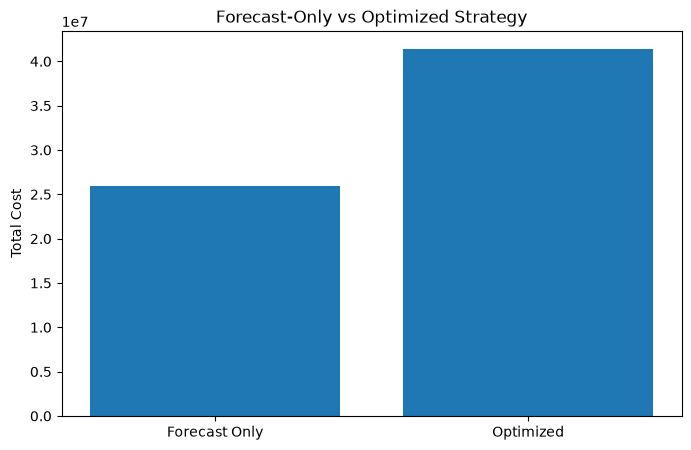

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Strategy"],
    comparison["Total Cost"]
)

plt.ylabel("Total Cost")
plt.title("Forecast-Only vs Optimized Strategy")

plt.show()

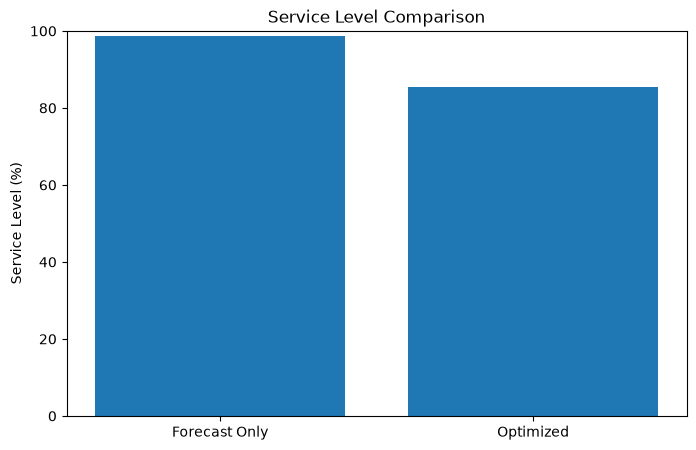

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Strategy"],
    comparison["Service Level"]
)

plt.ylabel("Service Level (%)")
plt.title("Service Level Comparison")

plt.ylim(0, 100)

plt.show()